# Phần 3: Kiểm định giả thuyết thống kê
---

**Nội dung notebook**

| Phần | Nội dung |
|---|---|
| **A** | Cơ sở lý thuyết: nền tảng kiểm định giả thuyết, T-test, Chi-square, ANOVA |
| **B** | Chuẩn bị dữ liệu (dùng file `clean_data.csv` đã làm sạch ở Phần 1) |
| **C** | Câu hỏi nghiên cứu 1: Hút thuốc có làm chi phí y tế khác biệt không? (**T-test**) |
| **D** | Câu hỏi nghiên cứu 2: Nhóm thể trạng BMI có chi phí y tế khác nhau không? (**ANOVA**) |
| **E** | Tổng kết |

---
# PHẦN A. CƠ SỞ LÝ THUYẾT

## A.0 Nền tảng chung của kiểm định giả thuyết

Ở các phần trước, chúng ta **mô tả** dữ liệu (thống kê mô tả, biểu đồ). Kiểm định giả thuyết trả lời câu hỏi tiếp theo: *khác biệt hoặc mối liên hệ quan sát được trên mẫu là có thật ở tổng thể, hay chỉ là do dao động ngẫu nhiên khi lấy mẫu?*

**Các khái niệm cốt lõi**

- **Giả thuyết không (H0):** khẳng định "không có khác biệt / không có liên hệ". Đây là giả thuyết được đem ra kiểm tra.
- **Giả thuyết đối (H1):** khẳng định ngược lại với H0 (có khác biệt / có liên hệ).
- **Mức ý nghĩa (α):** xác suất tối đa chấp nhận mắc **sai lầm loại I** (bác bỏ H0 trong khi H0 thật sự đúng). Thông thường chọn **α = 0,05**.
- **Thống kê kiểm định:** một con số tính từ mẫu (t, χ², F, ...) đo mức độ dữ liệu lệch khỏi những gì H0 dự đoán.
- **P-value (giá trị p):** xác suất thu được kết quả **cực đoan bằng hoặc hơn** kết quả quan sát, **với điều kiện H0 đúng**.

**Quy tắc quyết định**

| Kết quả | Quyết định | Diễn giải |
|---|---|---|
| p-value < α | Bác bỏ H0 | Có bằng chứng thống kê cho thấy khác biệt / liên hệ là có thật |
| p-value ≥ α | Không bác bỏ H0 | Chưa đủ bằng chứng (không có nghĩa là H0 chắc chắn đúng) |

**Những điều cần nhớ khi đọc p-value**

1. P-value **không** phải xác suất H0 đúng.
2. P-value nhỏ chỉ cho biết khác biệt **có thật**, **không** cho biết khác biệt **lớn hay nhỏ**. Vì vậy cần báo cáo thêm **độ lớn hiệu ứng** (effect size) như Cohen's d, Cramér's V, η².
3. Kiểm định chỉ phát hiện **mối liên hệ**, không chứng minh **quan hệ nhân quả**.

**Quy trình 5 bước thực hiện kiểm định:** (1) đặt giả thuyết H0/H1 → (2) chọn α → (3) kiểm tra điều kiện áp dụng → (4) tính thống kê kiểm định và p-value → (5) kết luận trong ngữ cảnh bài toán.

**Chọn phép kiểm định phù hợp**

| Biến phụ thuộc | Biến phân nhóm / biến còn lại | Số nhóm | Phép kiểm định |
|---|---|---|---|
| Định lượng | Phân loại | 2 | **T-test** |
| Định lượng | Phân loại | ≥ 3 | **ANOVA** |
| Phân loại | Phân loại | bất kỳ | **Chi-square** |

## A.1. T-test (Kiểm định T)

**Mục đích.** So sánh **giá trị trung bình của hai nhóm** để xác định chênh lệch giữa hai trung bình là có ý nghĩa thống kê hay chỉ do ngẫu nhiên.

**Các dạng T-test**

| Dạng | Tình huống sử dụng |
|---|---|
| *One-sample t-test* | So sánh trung bình một nhóm với một giá trị cho trước |
| *Independent samples t-test* | So sánh trung bình hai nhóm **độc lập** (ví dụ: hút thuốc và không hút thuốc) |
| *Paired t-test* | So sánh hai lần đo trên **cùng một đối tượng** (ví dụ: trước và sau điều trị) |

**Giả thuyết (hai phía)**

$$H_0:\ \mu_1 = \mu_2 \qquad\qquad H_1:\ \mu_1 \neq \mu_2$$

**Thống kê kiểm định.** Với hai nhóm độc lập, phương sai không nhất thiết bằng nhau, dùng **Welch's t-test**:

$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\dfrac{s_1^2}{n_1} + \dfrac{s_2^2}{n_2}}}$$

với $\bar{x}_i$ là trung bình mẫu, $s_i^2$ là phương sai mẫu, $n_i$ là cỡ mẫu của nhóm $i$. Bậc tự do tính theo công thức Welch–Satterthwaite:

$$df = \frac{\left(\dfrac{s_1^2}{n_1} + \dfrac{s_2^2}{n_2}\right)^2}{\dfrac{(s_1^2/n_1)^2}{n_1-1} + \dfrac{(s_2^2/n_2)^2}{n_2-1}}$$

**Điều kiện áp dụng**

1. Biến phụ thuộc là biến **định lượng**; biến phân nhóm có **đúng 2 nhóm**.
2. Các quan sát **độc lập** với nhau.
3. Dữ liệu mỗi nhóm xấp xỉ **phân phối chuẩn**. Khi cỡ mẫu lớn (n > 30 mỗi nhóm), *định lý giới hạn trung tâm* cho phép nới lỏng điều kiện này.
4. Phương sai hai nhóm bằng nhau (kiểm tra bằng **Levene**). Nếu không bằng nhau, dùng **Welch's t-test** (không yêu cầu điều kiện này).

*Phương án thay thế khi vi phạm điều kiện:* kiểm định phi tham số **Mann–Whitney U**.

**Độ lớn hiệu ứng: Cohen's d**

$$d = \frac{\bar{x}_1 - \bar{x}_2}{s_p}, \qquad s_p = \sqrt{\frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1+n_2-2}}$$

Quy ước: |d| ≈ 0,2 (nhỏ); ≈ 0,5 (trung bình); ≥ 0,8 (lớn).

**Cách đọc kết quả.** Nếu p < α thì bác bỏ H0: trung bình hai nhóm khác nhau có ý nghĩa thống kê.

## A.2. Chi-square (Kiểm định Chi bình phương về tính độc lập)

**Mục đích.** Kiểm tra có **mối liên hệ giữa hai biến phân loại** hay không, bằng cách so sánh **tần số quan sát** với **tần số kỳ vọng** nếu hai biến độc lập.

**Giả thuyết**

- H0: hai biến **độc lập** (không có mối liên hệ).
- H1: hai biến **có liên hệ** với nhau.

**Thống kê kiểm định**

$$\chi^2 = \sum \frac{(O - E)^2}{E}, \qquad E_{ij} = \frac{(\text{tổng hàng } i)\times(\text{tổng cột } j)}{N}$$

với O là tần số quan sát, E là tần số kỳ vọng. Bậc tự do: $df = (r-1)(c-1)$, trong đó r là số hàng, c là số cột của bảng chéo (contingency table).

**Điều kiện áp dụng**

1. Cả hai biến đều là biến **phân loại**.
2. Các quan sát **độc lập**, mỗi quan sát chỉ thuộc đúng một ô.
3. **Tần số kỳ vọng ở mỗi ô ≥ 5** (nếu không thỏa, dùng **Fisher's exact test** cho bảng 2×2).

**Độ lớn hiệu ứng: Cramér's V**

$$V = \sqrt{\frac{\chi^2}{N\cdot \min(r-1,\ c-1)}}$$

V nằm trong khoảng 0 đến 1. Với bảng 2×2 (df = 1): V ≈ 0,1 (nhỏ); ≈ 0,3 (trung bình); ≥ 0,5 (lớn).

**Cách đọc kết quả.** Nếu p < α thì bác bỏ H0: hai biến có liên hệ. Chi-square **chỉ cho biết có liên hệ hay không**, không cho biết chiều hướng nhân quả; muốn biết chiều hướng cần xem thêm bảng tỷ lệ phần trăm.

## A.3. ANOVA (Phân tích phương sai một yếu tố – One-way ANOVA)

**Mục đích.** So sánh **trung bình của 3 nhóm trở lên** cùng một lúc.

**Tại sao không chạy nhiều lần T-test?** Với k nhóm cần $\binom{k}{2}$ phép so sánh cặp. Mỗi phép có 5% nguy cơ sai lầm loại I, nên xác suất mắc ít nhất một sai lầm tăng nhanh. Ví dụ với 4 nhóm (6 cặp): $1-(1-0{,}05)^6 \approx 26\%$. ANOVA kiểm soát rủi ro này bằng **một** phép kiểm định tổng thể.

**Nguyên lý.** ANOVA so sánh hai nguồn biến thiên:

- **Giữa các nhóm** (between-group): do trung bình các nhóm khác nhau.
- **Trong nội bộ nhóm** (within-group): do sai khác ngẫu nhiên giữa các cá thể.

Nếu biến thiên giữa các nhóm lớn hơn nhiều so với trong nhóm, ta có cơ sở cho rằng trung bình các nhóm không đồng nhất.

**Giả thuyết**

$$H_0:\ \mu_1 = \mu_2 = \dots = \mu_k \qquad\qquad H_1:\ \text{có ít nhất một nhóm có trung bình khác các nhóm còn lại}$$

**Thống kê kiểm định**

$$F = \frac{MS_B}{MS_W} = \frac{SS_B/(k-1)}{SS_W/(N-k)}$$

trong đó $SS_B$ là tổng bình phương giữa các nhóm, $SS_W$ là tổng bình phương trong nhóm, k là số nhóm, N là tổng số quan sát. F càng lớn thì bằng chứng chống lại H0 càng mạnh.

**Điều kiện áp dụng**

1. Biến phụ thuộc là biến **định lượng**; biến phân nhóm có **từ 3 nhóm trở lên**.
2. Các quan sát **độc lập**.
3. Dữ liệu mỗi nhóm xấp xỉ **phân phối chuẩn** (nới lỏng khi cỡ mẫu lớn).
4. **Phương sai các nhóm đồng nhất** (kiểm tra bằng Levene).

*Phương án thay thế khi vi phạm:* **Welch's ANOVA** (không cần phương sai bằng nhau) hoặc **Kruskal–Wallis** (phi tham số).

**Độ lớn hiệu ứng: Eta bình phương**

$$\eta^2 = \frac{SS_B}{SS_T}$$

cho biết tỷ lệ biến thiên của biến phụ thuộc được giải thích bởi biến phân nhóm. Quy ước: ≈ 0,01 (nhỏ); ≈ 0,06 (trung bình); ≥ 0,14 (lớn).

**Kiểm định hậu nghiệm (post-hoc).** ANOVA chỉ cho biết *có ít nhất một nhóm khác biệt*, **không** chỉ ra *nhóm nào khác nhóm nào*. Khi p < α, cần chạy thêm **Tukey HSD** để so sánh từng cặp nhóm, đã hiệu chỉnh để kiểm soát sai lầm loại I.

**Cách đọc kết quả.** Nếu p < α thì bác bỏ H0, sau đó dùng Tukey HSD để xác định các cặp nhóm khác biệt.

---
# PHẦN B. CHUẨN BỊ DỮ LIỆU

Bộ dữ liệu gồm các biến: `age` (tuổi), `sex` (giới tính), `bmi` (chỉ số khối cơ thể), `children` (số con), `smoker` (có hút thuốc hay không), `region` (khu vực) và **`charges`** (chi phí y tế, đơn vị USD; biến mục tiêu).

In [17]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.options.display.float_format = "{:,.2f}".format

ALPHA = 0.05   # mức ý nghĩa dùng cho toàn bộ notebook

In [18]:
# Đọc file dữ liệu sạch (kết quả của Phần 1: đã xử lý missing values và duplicates)
df = pd.read_csv("data/clean_data.csv")

print(f"Kích thước dữ liệu: {df.shape[0]:,} dòng x {df.shape[1]} cột")
print(f"Giá trị thiếu: {df.isna().sum().sum()} | Dòng trùng lặp: {df.duplicated().sum()}")
print()
df.info()

Kích thước dữ liệu: 1,337 dòng x 7 cột
Giá trị thiếu: 0 | Dòng trùng lặp: 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.2+ KB


In [19]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,"16,884.92"
1,18,male,33.77,1,no,southeast,"1,725.55"
2,28,male,33.00,3,no,southeast,"4,449.46"
3,33,male,22.70,0,no,northwest,"21,984.47"
4,32,male,28.88,0,no,northwest,"3,866.86"


In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,"1,337.00",39.22,14.04,18.00,27.00,39.00,51.00,64.00
bmi,"1,337.00",30.66,6.10,15.96,26.29,30.40,34.70,53.13
children,"1,337.00",1.10,1.21,0.00,0.00,1.00,2.00,5.00
charges,"1,337.00","13,279.12","12,110.36","1,121.87","4,746.34","9,386.16","16,657.72","63,770.43"


---
# PHẦN C. CÂU HỎI NGHIÊN CỨU 1: HÚT THUỐC VÀ CHI PHÍ Y TẾ (T-test)

### Câu hỏi
> **Chi phí y tế trung bình của người hút thuốc có khác biệt so với người không hút thuốc hay không?**

### Thiết kế kiểm định

| Thành phần | Nội dung |
|---|---|
| Biến phụ thuộc | `charges` (định lượng) |
| Biến phân nhóm | `smoker` (2 nhóm: `yes` / `no`) |
| Phép kiểm định | Independent samples t-test (Welch) |
| H0 | $\mu_{hút\ thuốc} = \mu_{không\ hút\ thuốc}$ |
| H1 | $\mu_{hút\ thuốc} \neq \mu_{không\ hút\ thuốc}$ |
| Mức ý nghĩa | α = 0,05 |

### Bước 1. Thống kê mô tả và trực quan hóa

In [21]:
smoker_charges     = df.loc[df["smoker"] == "yes", "charges"]
non_smoker_charges = df.loc[df["smoker"] == "no",  "charges"]

summary1 = df.groupby("smoker")["charges"].agg(["count", "mean", "median", "std", "min", "max"])
summary1.index = summary1.index.map({"no": "Không hút thuốc", "yes": "Hút thuốc"})
summary1

,count,mean,median,std,min,max
smoker,,,,,,
Không hút thuốc,1063,"8,440.66","7,345.73","5,992.97","1,121.87","36,910.61"
Hút thuốc,274,"32,050.23","34,456.35","11,541.55","12,829.46","63,770.43"


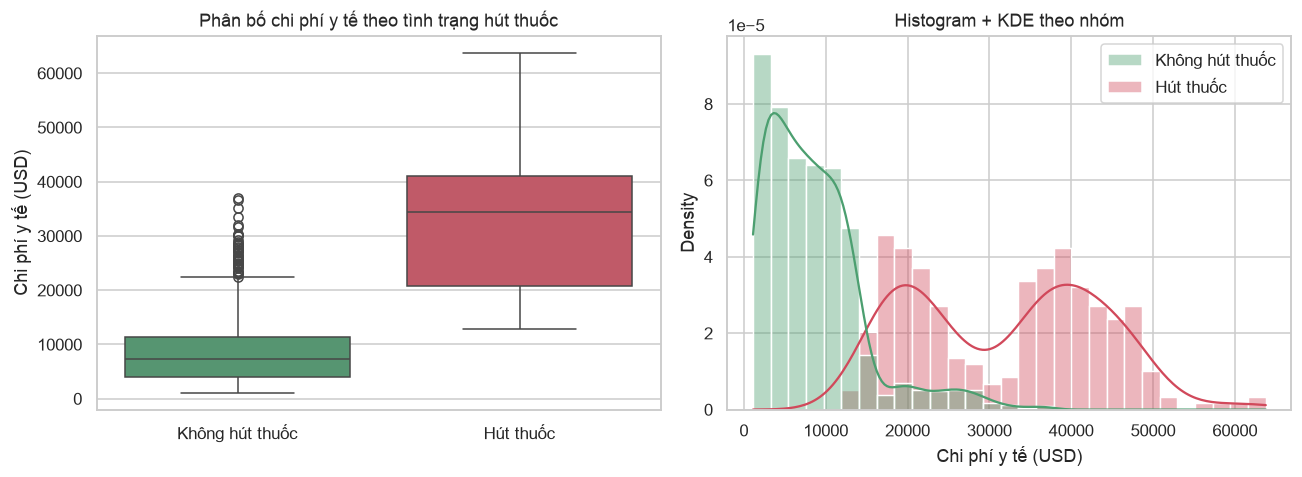

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_df = df.assign(nhom=df["smoker"].map({"no": "Không hút thuốc", "yes": "Hút thuốc"}))
order   = ["Không hút thuốc", "Hút thuốc"]
palette = {"Không hút thuốc": "#4C9F70", "Hút thuốc": "#D1495B"}

sns.boxplot(data=plot_df, x="nhom", y="charges", order=order, palette=palette, ax=axes[0])
axes[0].set_xlabel("")
axes[0].set_ylabel("Chi phí y tế (USD)")
axes[0].set_title("Phân bố chi phí y tế theo tình trạng hút thuốc")

sns.histplot(data=plot_df, x="charges", hue="nhom", hue_order=order, kde=True, stat="density",
             common_norm=False, palette=palette, alpha=0.4, ax=axes[1])
axes[1].set_xlabel("Chi phí y tế (USD)")
axes[1].set_title("Histogram + KDE theo nhóm")
axes[1].get_legend().set_title("")

plt.tight_layout()
plt.show()

### Bước 2. Kiểm tra điều kiện áp dụng

In [23]:
# (a) Phân phối chuẩn: Shapiro-Wilk (H0: dữ liệu có phân phối chuẩn)
print("Kiểm tra phân phối chuẩn (Shapiro-Wilk):")
for name, g in [("Hút thuốc", smoker_charges), ("Không hút thuốc", non_smoker_charges)]:
    w, p = stats.shapiro(g)
    print(f"  - {name:<16}: n = {len(g):>4}, W = {w:.4f}, p = {p:.2e}, độ lệch (skew) = {stats.skew(g):.2f}")

# (b) Phương sai đồng nhất: Levene (H0: phương sai hai nhóm bằng nhau)
lev_stat, lev_p = stats.levene(smoker_charges, non_smoker_charges)
print(f"\nKiểm tra phương sai đồng nhất (Levene): thống kê = {lev_stat:.2f}, p = {lev_p:.2e}")

Kiểm tra phân phối chuẩn (Shapiro-Wilk):
  - Hút thuốc       : n =  274, W = 0.9396, p = 3.62e-09, độ lệch (skew) = 0.13
  - Không hút thuốc : n = 1063, W = 0.8729, p = 1.50e-28, độ lệch (skew) = 1.54

Kiểm tra phương sai đồng nhất (Levene): thống kê = 332.47, p = 1.67e-66


**Nhận xét điều kiện:**

- **Phân phối chuẩn bị vi phạm** ở cả hai nhóm (Shapiro p rất nhỏ; nhóm không hút thuốc lệch phải rõ rệt với độ lệch ≈ 1,54). Tuy nhiên mỗi nhóm có hàng trăm quan sát (274 và 1.063), nên theo định lý giới hạn trung tâm, T-test vẫn đáng tin cậy. Để chắc chắn, ta kiểm tra lại bằng Mann–Whitney U (không đòi hỏi phân phối chuẩn).
- **Phương sai hai nhóm khác nhau rõ rệt** (Levene p rất nhỏ) → bắt buộc dùng **Welch's t-test** (`equal_var=False`) thay vì T-test thông thường.
- Các quan sát độc lập vì mỗi dòng là một cá nhân khác nhau.

### Bước 3. Chạy kiểm định

In [24]:
# --- Welch's t-test ---
t_stat, p_val = stats.ttest_ind(smoker_charges, non_smoker_charges, equal_var=False)

n1, n2 = len(smoker_charges), len(non_smoker_charges)
m1, m2 = smoker_charges.mean(), non_smoker_charges.mean()
v1, v2 = smoker_charges.var(ddof=1), non_smoker_charges.var(ddof=1)

# Bậc tự do Welch-Satterthwaite và khoảng tin cậy 95% cho chênh lệch trung bình
se   = np.sqrt(v1 / n1 + v2 / n2)
df_w = (v1 / n1 + v2 / n2) ** 2 / ((v1 / n1) ** 2 / (n1 - 1) + (v2 / n2) ** 2 / (n2 - 1))
diff = m1 - m2
t_crit = stats.t.ppf(1 - ALPHA / 2, df_w)
ci_low, ci_high = diff - t_crit * se, diff + t_crit * se

# --- Độ lớn hiệu ứng: Cohen's d ---
sp = np.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2))
cohen_d = diff / sp

# --- Kiểm tra chéo bằng Mann-Whitney U (phi tham số) ---
u_stat, u_p = stats.mannwhitneyu(smoker_charges, non_smoker_charges, alternative="two-sided")

print("KẾT QUẢ WELCH'S T-TEST")
print("-" * 55)
print(f"Trung bình nhóm hút thuốc       : {m1:>12,.2f} USD")
print(f"Trung bình nhóm không hút thuốc : {m2:>12,.2f} USD")
print(f"Chênh lệch trung bình           : {diff:>12,.2f} USD  (gấp {m1 / m2:.2f} lần)")
print(f"Khoảng tin cậy 95% của chênh lệch: [{ci_low:,.2f} ; {ci_high:,.2f}] USD")
print(f"Thống kê t = {t_stat:.3f}, bậc tự do = {df_w:.1f}")
print(f"P-value = {p_val:.2e}")
print(f"Cohen's d = {cohen_d:.2f}")
print()
print(f"Kiểm tra chéo Mann-Whitney U: U = {u_stat:,.0f}, p = {u_p:.2e}")
print("-" * 55)
if p_val < ALPHA:
    print(f"=> p < {ALPHA}: BÁC BỎ H0. Chi phí y tế trung bình giữa hai nhóm khác nhau có ý nghĩa thống kê.")
else:
    print(f"=> p >= {ALPHA}: KHÔNG BÁC BỎ H0. Chưa đủ bằng chứng về sự khác biệt.")

KẾT QUẢ WELCH'S T-TEST
-------------------------------------------------------
Trung bình nhóm hút thuốc       :    32,050.23 USD
Trung bình nhóm không hút thuốc :     8,440.66 USD
Chênh lệch trung bình           :    23,609.57 USD  (gấp 3.80 lần)
Khoảng tin cậy 95% của chênh lệch: [22,190.79 ; 25,028.35] USD
Thống kê t = 32.742, bậc tự do = 311.9
P-value = 6.26e-103
Cohen's d = 3.16

Kiểm tra chéo Mann-Whitney U: U = 283,859, p = 5.75e-130
-------------------------------------------------------
=> p < 0.05: BÁC BỎ H0. Chi phí y tế trung bình giữa hai nhóm khác nhau có ý nghĩa thống kê.


### Bước 4. Giải thích kết quả

- **Giải thích P-value:** p ≈ 6,3 × 10⁻¹⁰³ (nhỏ hơn α = 0,05 rất nhiều). Nói cách khác, *nếu* thật sự không có khác biệt chi phí giữa người hút thuốc và không hút thuốc (H0 đúng) thì xác suất quan sát được chênh lệch lớn như trong mẫu gần như bằng 0. Do đó ta **bác bỏ H0**.
- **Độ lớn khác biệt:** người hút thuốc có chi phí y tế trung bình khoảng **32.050 USD**, so với **8.441 USD** của người không hút thuốc, tức cao gấp khoảng **3,8 lần**. Khoảng tin cậy 95% của chênh lệch là khoảng **22.190 đến 25.030 USD**. Cohen's d ≈ 3,16 là hiệu ứng **rất lớn** (vượt xa ngưỡng 0,8).
- **Kiểm tra độ vững:** Mann–Whitney U (không phụ thuộc phân phối chuẩn) cho cùng kết luận (p ≈ 5,7 × 10⁻¹³⁰), nên kết quả không phụ thuộc vào việc dữ liệu có chuẩn hay không.

**Kết luận câu hỏi 1:** Hút thuốc có liên quan mạnh đến chi phí y tế. Người hút thuốc có chi phí cao hơn đáng kể về mặt thống kê, và mức chênh lệch lớn về mặt thực tiễn.

---
# PHẦN D. CÂU HỎI NGHIÊN CỨU 2: BMI VÀ CHI PHÍ Y TẾ (ANOVA)

### Câu hỏi
> **Chi phí y tế trung bình có khác nhau giữa các nhóm thể trạng (phân loại theo BMI) hay không?**

### Thiết kế kiểm định

BMI là biến liên tục nên trước hết ta chia thành 4 nhóm theo **chuẩn phân loại của WHO**:

| Nhóm | Khoảng BMI |
|---|---|
| Thiếu cân | < 18,5 |
| Bình thường | 18,5 đến < 25 |
| Thừa cân | 25 đến < 30 |
| Béo phì | ≥ 30 |

| Thành phần | Nội dung |
|---|---|
| Biến phụ thuộc | `charges` (định lượng) |
| Biến phân nhóm | `bmi_group` (4 nhóm) |
| Phép kiểm định | One-way ANOVA (kèm Welch's ANOVA, Kruskal–Wallis và Tukey HSD) |
| H0 | $\mu_{thiếu\ cân} = \mu_{bình\ thường} = \mu_{thừa\ cân} = \mu_{béo\ phì}$ |
| H1 | Có ít nhất một nhóm có chi phí trung bình khác các nhóm còn lại |
| Mức ý nghĩa | α = 0,05 |

### Bước 1. Phân nhóm BMI và thống kê mô tả

In [25]:
bins   = [0, 18.5, 25, 30, np.inf]
labels = ["Thiếu cân", "Bình thường", "Thừa cân", "Béo phì"]
df["bmi_group"] = pd.cut(df["bmi"], bins=bins, labels=labels, right=False)

summary2 = df.groupby("bmi_group", observed=True)["charges"].agg(["count", "mean", "median", "std"])
summary2

,count,mean,median,std
bmi_group,,,,
Thiếu cân,20,"8,852.20","6,759.26","7,735.04"
Bình thường,225,"10,409.34","8,603.82","7,505.58"
Thừa cân,386,"10,987.51","8,659.38","8,039.46"
Béo phì,706,"15,572.04","10,003.65","14,553.20"


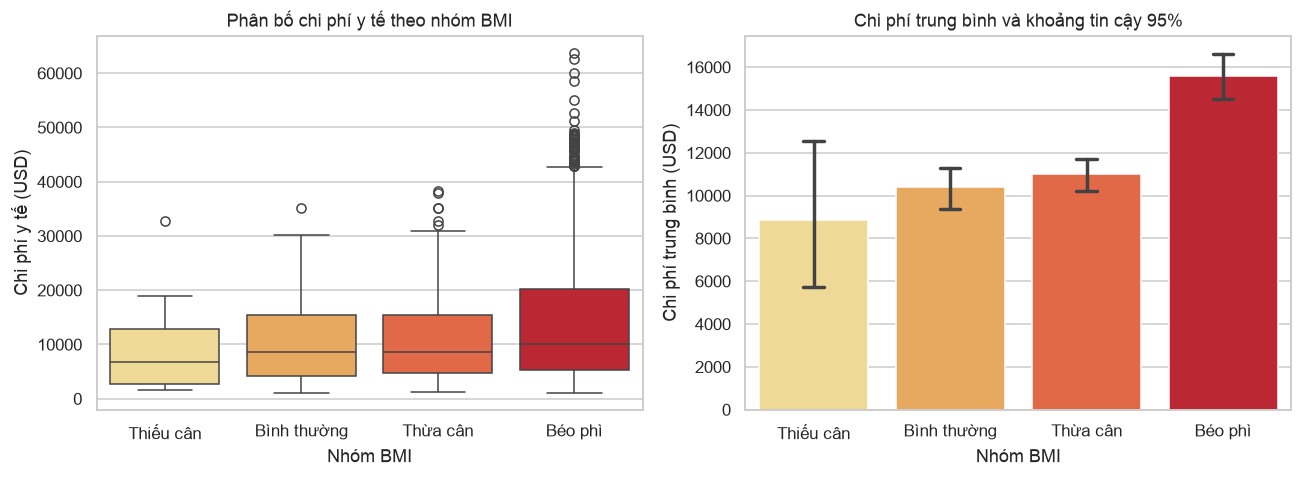

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(data=df, x="bmi_group", y="charges", palette="YlOrRd", ax=axes[0])
axes[0].set_xlabel("Nhóm BMI")
axes[0].set_ylabel("Chi phí y tế (USD)")
axes[0].set_title("Phân bố chi phí y tế theo nhóm BMI")

sns.barplot(data=df, x="bmi_group", y="charges", errorbar=("ci", 95),
            palette="YlOrRd", capsize=0.15, ax=axes[1])
axes[1].set_xlabel("Nhóm BMI")
axes[1].set_ylabel("Chi phí trung bình (USD)")
axes[1].set_title("Chi phí trung bình và khoảng tin cậy 95%")

plt.tight_layout()
plt.show()

### Bước 2. Kiểm tra điều kiện áp dụng

In [27]:
groups = [g["charges"].values for _, g in df.groupby("bmi_group", observed=True)]
group_names = labels

print("Kiểm tra phân phối chuẩn (Shapiro-Wilk) theo từng nhóm:")
for name, g in zip(group_names, groups):
    w, p = stats.shapiro(g)
    print(f"  - {name:<12}: n = {len(g):>4}, p = {p:.2e}")

lev_stat, lev_p = stats.levene(*groups)
print(f"\nKiểm tra phương sai đồng nhất (Levene): thống kê = {lev_stat:.2f}, p = {lev_p:.2e}")

Kiểm tra phân phối chuẩn (Shapiro-Wilk) theo từng nhóm:
  - Thiếu cân   : n =   20, p = 2.84e-03
  - Bình thường : n =  225, p = 7.19e-10
  - Thừa cân    : n =  386, p = 2.01e-15
  - Béo phì     : n =  706, p = 2.60e-28

Kiểm tra phương sai đồng nhất (Levene): thống kê = 22.29, p = 4.41e-14


**Nhận xét điều kiện:**

- **Phân phối không chuẩn** ở cả 4 nhóm (dữ liệu chi phí lệch phải).
- **Phương sai không đồng nhất** (Levene p rất nhỏ): điều kiện của ANOVA cổ điển bị vi phạm. Vì vậy ngoài ANOVA, ta chạy thêm **Welch's ANOVA** (không cần phương sai bằng nhau) và **Kruskal–Wallis** (phi tham số) để đối chiếu.
- Nhóm *Thiếu cân* chỉ có **20 quan sát**, nên các kết luận liên quan đến nhóm này có độ tin cậy thấp hơn.

### Bước 3. Chạy kiểm định

In [ ]:
# --- (1) One-way ANOVA cổ điển ---
f_stat, p_anova = stats.f_oneway(*groups)

# --- (2) Welch's ANOVA ---
k = len(groups)
n_i = np.array([len(g) for g in groups])
m_i = np.array([g.mean() for g in groups])
v_i = np.array([g.var(ddof=1) for g in groups])
w_i = n_i / v_i
W = w_i.sum()
m_w = (w_i * m_i).sum() / W
lam = ((1 - w_i / W) ** 2 / (n_i - 1)).sum()
f_welch = ((w_i * (m_i - m_w) ** 2).sum() / (k - 1)) / (1 + 2 * (k - 2) / (k ** 2 - 1) * lam)
df2_welch = (k ** 2 - 1) / (3 * lam)
p_welch = stats.f.sf(f_welch, k - 1, df2_welch)

# --- (3) Kruskal-Wallis (phi tham số) ---
h_stat, p_kw = stats.kruskal(*groups)

# --- Độ lớn hiệu ứng: eta bình phương ---
grand_mean = df["charges"].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
ss_total   = ((df["charges"] - grand_mean) ** 2).sum()
eta_sq = ss_between / ss_total

print("KẾT QUẢ SO SÁNH CHI PHÍ Y TẾ GIỮA 4 NHÓM BMI")
print("-" * 62)
print(f"One-way ANOVA   : F = {f_stat:6.2f}, df = ({k-1}, {len(df)-k}), p = {p_anova:.2e}")
print(f"Welch's ANOVA   : F = {f_welch:6.2f}, df = ({k-1}, {df2_welch:.1f}), p = {p_welch:.2e}")
print(f"Kruskal-Wallis  : H = {h_stat:6.2f}, df = {k-1}, p = {p_kw:.2e}")
print(f"Eta bình phương = {eta_sq:.3f}  (BMI giải thích khoảng {eta_sq*100:.1f}% biến thiên của chi phí)")
print("-" * 62)
if p_anova < ALPHA:
    print(f"=> p < {ALPHA}: BÁC BỎ H0. Có ít nhất một nhóm BMI có chi phí trung bình khác biệt.")
else:
    print(f"=> p >= {ALPHA}: KHÔNG BÁC BỎ H0.")

KẾT QUẢ SO SÁNH CHI PHÍ Y TẾ GIỮA 4 NHÓM BMI
--------------------------------------------------------------
One-way ANOVA   : F =  18.87, df = (3, 1333), p = 5.44e-12
Welch's ANOVA   : F =  20.34, df = (3, 92.7), p = 3.27e-10
Kruskal-Wallis  : H =  17.05, df = 3, p = 6.91e-04
Eta bình phương = 0.041  (BMI giải thích khoảng 4.1% biến thiên của chi phí)
--------------------------------------------------------------
=> p < 0.05: BÁC BỎ H0. Có ít nhất một nhóm BMI có chi phí trung bình khác biệt.


### Bước 4. Kiểm định hậu nghiệm Tukey HSD

ANOVA mới chỉ cho biết *có khác biệt*. Tukey HSD sẽ chỉ rõ **cặp nhóm nào** khác nhau.

In [29]:
tukey = stats.tukey_hsd(*groups)
ci = tukey.confidence_interval(confidence_level=1 - ALPHA)

rows = []
for i in range(k):
    for j in range(i + 1, k):
        rows.append({
            "Cặp so sánh": f"{group_names[j]} - {group_names[i]}",
            "Chênh lệch TB (USD)": -tukey.statistic[i, j],
            "CI 95% dưới": -ci.high[i, j],
            "CI 95% trên": -ci.low[i, j],
            "P-value": tukey.pvalue[i, j],
            "Khác biệt?": "Có" if tukey.pvalue[i, j] < ALPHA else "Không",
        })

tukey_table = pd.DataFrame(rows)
tukey_table["P-value"] = tukey_table["P-value"].map(lambda p: "< 0.001" if p < 0.001 else f"{p:.3f}")
tukey_table

,Cặp so sánh,Chênh lệch TB (USD),CI 95% dưới,CI 95% trên,P-value,Khác biệt?
0,Bình thường - Thiếu cân,"1,557.14","-5,569.85","8,684.13",0.943,Không
1,Thừa cân - Thiếu cân,"2,135.31","-4,869.30","9,139.91",0.862,Không
2,Béo phì - Thiếu cân,"6,719.84",-206.12,"13,645.81",0.061,Không
3,Thừa cân - Bình thường,578.17,"-1,983.74","3,140.09",0.938,Không
4,Béo phì - Bình thường,"5,162.70","2,824.35","7,501.06",< 0.001,Có
5,Béo phì - Thừa cân,"4,584.53","2,651.03","6,518.03",< 0.001,Có


### Bước 5. Kiểm tra bổ sung: kết quả có còn đúng khi loại bỏ yếu tố hút thuốc?

Ở Câu hỏi 1 ta thấy hút thuốc ảnh hưởng rất mạnh đến chi phí. Cần chắc rằng sự khác biệt giữa các nhóm BMI **không chỉ do** tỷ lệ người hút thuốc khác nhau giữa các nhóm. Ta lặp lại phép kiểm định **chỉ trên nhóm không hút thuốc**.

In [30]:
# Tỷ lệ người hút thuốc trong từng nhóm BMI
print("Tỷ lệ người hút thuốc theo nhóm BMI:")
display((pd.crosstab(df["bmi_group"], df["smoker"], normalize="index")["yes"] * 100)
        .round(1).rename("% hút thuốc").to_frame())

# Lặp lại kiểm định chỉ với người không hút thuốc
ns = df[df["smoker"] == "no"]
groups_ns = [g["charges"].values for _, g in ns.groupby("bmi_group", observed=True)]
f_ns, p_ns = stats.f_oneway(*groups_ns)
h_ns, p_kw_ns = stats.kruskal(*groups_ns)

print(f"\nChỉ nhóm không hút thuốc (n = {len(ns):,}):")
print(f"  One-way ANOVA : F = {f_ns:.2f}, p = {p_ns:.4f}")
print(f"  Kruskal-Wallis: H = {h_ns:.2f}, p = {p_kw_ns:.4f}")

Tỷ lệ người hút thuốc theo nhóm BMI:


,% hút thuốc
bmi_group,
Thiếu cân,25.00
Bình thường,22.20
Thừa cân,19.20
Béo phì,20.50



Chỉ nhóm không hút thuốc (n = 1,063):
  One-way ANOVA : F = 3.11, p = 0.0255
  Kruskal-Wallis: H = 12.93, p = 0.0048


### Bước 6. Giải thích kết quả

- **Giải thích P-value:** cả ba phép kiểm định đều cho p rất nhỏ (ANOVA: p ≈ 5,4 × 10⁻¹²; Welch: p ≈ 3,3 × 10⁻¹⁰; Kruskal–Wallis: p ≈ 0,0007), đều nhỏ hơn α = 0,05. Nếu chi phí y tế trung bình thật sự bằng nhau giữa 4 nhóm BMI thì xác suất thấy được khác biệt như trong mẫu là cực kỳ nhỏ, nên ta **bác bỏ H0**. Việc ba phương pháp (trong đó có hai phương pháp không đòi hỏi phương sai đồng nhất) cùng đi đến một kết luận cho thấy kết quả **vững**.
- **Nhóm nào khác nhóm nào (Tukey HSD):** sự khác biệt có ý nghĩa thống kê **chỉ xuất hiện ở nhóm Béo phì**: chi phí trung bình của nhóm Béo phì (khoảng **15.572 USD**) cao hơn nhóm Bình thường (10.409 USD) khoảng 5.200 USD và cao hơn nhóm Thừa cân (10.988 USD) khoảng 4.600 USD. Các cặp còn lại (Thiếu cân, Bình thường, Thừa cân so với nhau) **không** khác biệt có ý nghĩa. Cặp Béo phì với Thiếu cân có p ≈ 0,06, chưa đạt ngưỡng 0,05, nhưng cần lưu ý nhóm Thiếu cân chỉ có 20 quan sát nên thiếu sức mạnh thống kê.
- **Độ lớn hiệu ứng:** η² ≈ 0,04 nghĩa là nhóm BMI chỉ giải thích khoảng **4%** biến thiên của chi phí, tức hiệu ứng **nhỏ đến trung bình**. Đây là điểm quan trọng: khác biệt có thật (p nhỏ) nhưng **không lớn** như yếu tố hút thuốc.
- **Kiểm tra bổ sung:** tỷ lệ hút thuốc giữa các nhóm BMI khá tương đồng (khoảng 19% đến 25%), và khi chỉ xét người không hút thuốc, khác biệt giữa các nhóm BMI **vẫn có ý nghĩa** (ANOVA p ≈ 0,025; Kruskal–Wallis p ≈ 0,005). Vậy ảnh hưởng của BMI không chỉ là hệ quả của việc hút thuốc.

**Kết luận câu hỏi 2:** Chi phí y tế có khác nhau giữa các nhóm BMI, và khác biệt chủ yếu đến từ nhóm **Béo phì** có chi phí cao hơn các nhóm còn lại. Tuy nhiên, mức độ ảnh hưởng của BMI nhỏ hơn nhiều so với hút thuốc.

**Diễn giải**

- **P-value:** p ≈ 0,005 < 0,05 nên **bác bỏ H0**: có bằng chứng thống kê cho thấy giới tính và việc hút thuốc có liên hệ. Kết luận không đổi khi dùng hiệu chỉnh Yates (p ≈ 0,006).
- **Chiều hướng (xem bảng tỷ lệ):** khoảng **23,6%** nam giới hút thuốc, so với **17,4%** ở nữ giới.
- **Độ lớn hiệu ứng:** Cramér's V ≈ 0,08, tức mối liên hệ **rất yếu** (dưới ngưỡng 0,1). Liên hệ có thật nhưng chênh lệch giữa hai giới không lớn, do cỡ mẫu lớn nên kiểm định vẫn phát hiện được.

---
# PHẦN E. TỔNG KẾT

### Tổng hợp kết quả

| # | Câu hỏi nghiên cứu | Phép kiểm định | P-value | Độ lớn hiệu ứng | Kết luận |
|---|---|---|---|---|---|
| 1 | Chi phí y tế của người hút thuốc có khác người không hút thuốc? | Welch's t-test | ≈ 6,3 × 10⁻¹⁰³ | Cohen's d ≈ 3,16 (rất lớn) | Có khác biệt; người hút thuốc chi phí cao gấp ~3,8 lần |
| 2 | Chi phí y tế có khác nhau giữa các nhóm BMI? | ANOVA + Tukey HSD | ≈ 5,4 × 10⁻¹² | η² ≈ 0,04 (nhỏ) | Có khác biệt; chủ yếu do nhóm Béo phì cao hơn |

### Liên hệ

- **Mục tiêu 1 (hút thuốc và chi phí):** hút thuốc là yếu tố có ảnh hưởng **mạnh nhất**, đây là biến cần được ưu tiên đưa vào mô hình dự đoán.
- **Mục tiêu 2 (BMI và chi phí):** BMI có ảnh hưởng thật nhưng ở mức vừa phải, tập trung ở nhóm béo phì. Gợi ý cho phần mô hình: có thể tạo biến cờ "béo phì" (BMI ≥ 30) hoặc xét **tương tác giữa BMI và hút thuốc**.